<a href="https://colab.research.google.com/github/maragraefer/PRA3024/blob/main/LHCb_2026_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Welcome to Week 3!

We will be focussing in Particle Physics Analysis and detecting matter/antimatter assymetries in the production of certain types of particles.


![LHCb detector](https://www1b.physik.rwth-aachen.de/~schael/LHCb_files/LHCB%20PREVIEW-white-bg.jpg)

The data we are using comes from LHCb - one of the experiments at LHC. It is a highly specialised detector aimed at detecting decays involving the B-quark. Unlike the other major experiments, LHCb detects particles very close to the source and looks almost exclusively in the forward direction - this gives the detector many advantages compared to other experiments at LHC.

In order to get started, we need to access the [ROOT framework](https://root.cern.ch/) through a python package for that - [upROOT](https://pypi.org/project/uproot/) and download some datafiles into your environment!.

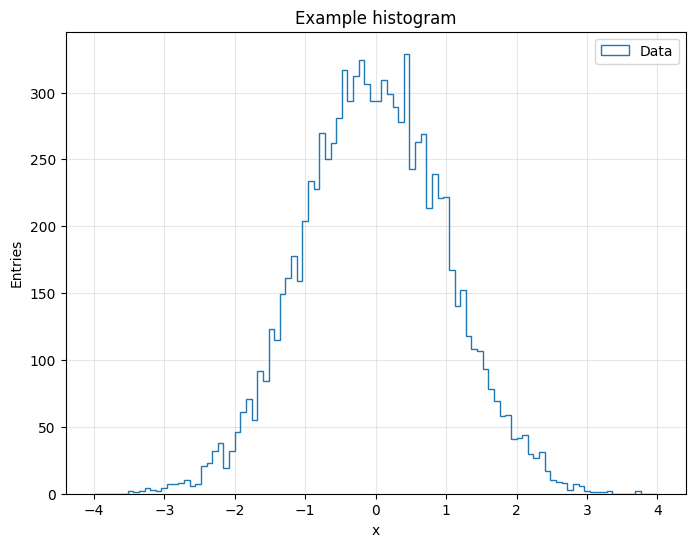

In [1]:
# We use NumPy for numerical work and random numbers
# Matplotlib is used for plotting as before
import numpy as np
import matplotlib.pyplot as plt

# SciPy provides fitting tools, similar to ROOT's Fit("gaus")
from scipy.stats import norm


# ------------------------------------------------------------
# 1. Generate Gaussian-distributed random numbers
#    (equivalent to h.FillRandom("gaus"))
# ------------------------------------------------------------

# Mean (mu) and standard deviation (sigma) of the Gaussian
mu = 0.0
sigma = 1.0

# Number of entries to generate (like number of fills)
n_entries = 10000

# Generate random data
data = np.random.normal(loc=mu, scale=sigma, size=n_entries)


# ------------------------------------------------------------
# 2. Create a histogram (We will do this alot today...))
# ------------------------------------------------------------

# Histogram settings - choose your own
n_bins = 100
x_min, x_max = -4, 4

# Create the figure and axes
fig, ax = plt.subplots(figsize=(8, 6))


counts, bin_edges, _ = ax.hist(
    data,
    bins=n_bins,
    range=(x_min, x_max),
    histtype="step",
    label="Data"
)


# ------------------------------------------------------------
# 3. Labels, title, and final touches
# ------------------------------------------------------------

ax.set_title("Example histogram")
ax.set_xlabel("x")
ax.set_ylabel("Entries")

ax.legend()
ax.grid(alpha=0.3)

# Display the plot
plt.show()



All being well - this should give no errors and we should have some kind of Gaussian distribution above.

We now want to do two things, install uproot - and get our data file from the CERN open data storage location.

This will probably be ratelimited very quickly, so you can find it on Canvas here: https://canvas.maastrichtuniversity.nl/courses/26553/files/6101104?module_item_id=1009080

Then upload it directly.

In [2]:
!pip install uproot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.8/393.8 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 919.6/919.6 kB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 656.7/656.7 kB 31.9 MB/s eta 0:00:00


In [3]:
!mkdir LHCb_Data && cd LHCb_Data && wget http://opendata.cern.ch/record/4900/files/B2HHH_MagnetDown.root

--2026-02-24 21:39:53--  http://opendata.cern.ch/record/4900/files/B2HHH_MagnetDown.root
Resolving opendata.cern.ch (opendata.cern.ch)... 137.138.6.31, 2001:1458:201:8b::100:1c8
Connecting to opendata.cern.ch (opendata.cern.ch)|137.138.6.31|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 666484974 (636M) [application/octet-stream]
Saving to: ‘B2HHH_MagnetDown.root’

B2HHH_MagnetDown.ro 100%[===================>] 635.61M  16.4MB/s    in 40s     

2026-02-24 21:40:33 (16.0 MB/s) - ‘B2HHH_MagnetDown.root’ saved [666484974/666484974]



In [4]:
import uproot

# Open the ROOT file
file = uproot.open("/content/LHCb_Data/B2HHH_MagnetDown.root")

# List contents (shows us what is inside)
file.keys()

# Access the tree
tree = file["DecayTree"]

# Read one branch as a NumPy array
px = tree["H1_PX"].array(library="np")

px

array([  375.2842054 , -4985.13078543, -1265.45654435, ...,
        2606.91083928,  -294.71098895,   499.04234923])

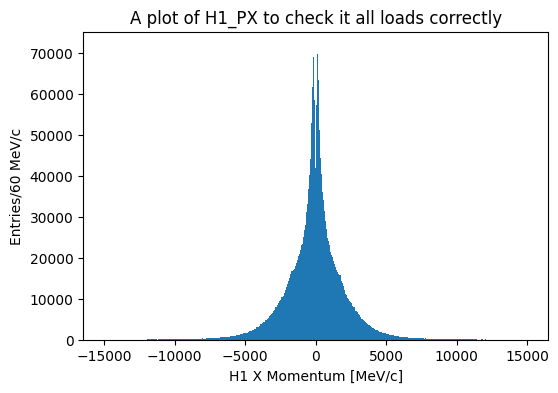

In [5]:
# now our data is an array - we can plot it :)

plt.figure(figsize=(6, 4))


#play with the variables below ...
plt.hist(
    px,
    bins=1000,
    range=(-15000, 15000),
    histtype="bar"
)

#Add some labels...

plt.xlabel("H1 X Momentum [MeV/c]")
plt.ylabel("Entries/60 MeV/c")
plt.title("A plot of H1_PX to check it all loads correctly")

plt.show()

This is the point at which the setup is all working - you can proceed below if you want to look at a basic guide to fitting functions to data using numpy etc.

<>:44: SyntaxWarning: invalid escape sequence '\m'
<>:44: SyntaxWarning: invalid escape sequence '\s'
<>:44: SyntaxWarning: invalid escape sequence '\m'
<>:44: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-633907596.py:44: SyntaxWarning: invalid escape sequence '\m'
  label=f"Gaussian fit\n$\mu={fit_mu:.3f}$, $\sigma={fit_sigma:.3f}$"
/tmp/ipython-input-633907596.py:44: SyntaxWarning: invalid escape sequence '\s'
  label=f"Gaussian fit\n$\mu={fit_mu:.3f}$, $\sigma={fit_sigma:.3f}$"


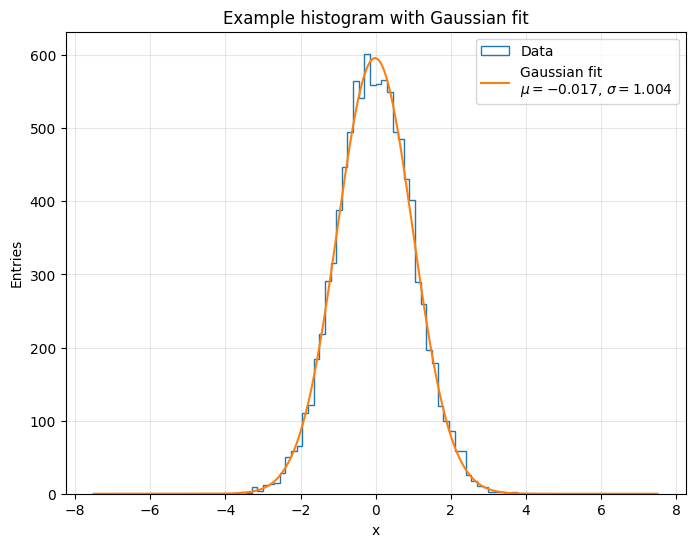

In [6]:
# Histogram settings - choose your own
n_bins = 100
x_min, x_max =-7.5, 7.5

# Create the figure and axes
fig, ax = plt.subplots(figsize=(8, 6))


counts, bin_edges, _ = ax.hist(
    data,
    bins=n_bins,
    range=(x_min, x_max),
    histtype="step",
    label="Data"
)

# ------------------------------------------------------------
# Now we perform a Gaussian fit
# ------------------------------------------------------------

# Fit a normal distribution to the data
# norm.fit returns the fitted mean and standard deviation
fit_mu, fit_sigma = norm.fit(data)

# Create x values for drawing the fitted function
x = np.linspace(x_min, x_max, 400)

# Evaluate the fitted Gaussian probability density function
pdf = norm.pdf(x, fit_mu, fit_sigma)

# Convert PDF to expected histogram counts
# (ROOT does this internally; here we scale manually)
bin_width = (x_max - x_min) / n_bins
fit_y = pdf * n_entries * bin_width


# ------------------------------------------------------------
# Draw the fitted Gaussian on top of the histogram
# ------------------------------------------------------------

ax.plot(
    x,
    fit_y,
    label=f"Gaussian fit\n$\mu={fit_mu:.3f}$, $\sigma={fit_sigma:.3f}$"
)


# ------------------------------------------------------------
# abels, title, and final touches
# ------------------------------------------------------------

ax.set_title("Example histogram with Gaussian fit")
ax.set_xlabel("x")
ax.set_ylabel("Entries")

ax.legend()
ax.grid(alpha=0.3)

# Display the plot (equivalent to c.Draw())
plt.show()


## If you are **Here** - and Chris did not make the introduction yet - it's time for a coffee - take a break and wait for instructions about how to proceed.

#Why are we here?

This week is about finding out something about one of the fundemental questions in physics. Why do we have "stuff".

According to many of our models, and according to many measurements in particle physics, matter and anti-matter appear to be produced in equal quantities.

However, when one looks at the Universe in general, we have more matter than anti-matter left - so there need to be some processes where anti-matter and matter are not produced equally. You can find out more about the Matter/Anti-Matter Asymmetry [here](http://press.web.cern.ch/backgrounders/matterantimatter-asymmetry)

One place we look for this asymetry is in [charge-partity (CP) violation](https://www.symmetrymagazine.org/article/october-2005/explain-it-in-60-seconds) in particle physics processes. This essentially says that the processes that happen in the anti-particle version of a decay do not **exactly** match to the processes that happen in the particle version of the decay.



---



At LHCb, we produce both particle of the  B<sup>+</sup> meson and it's antiparticle the B<sup>-</sup> meson.

We cannot detect these mesons directly. They decay into other things before we have a chance to measure them properly. So we collect data on the decay products, often called daughter particles. There are 524 [documented](http://pdg.lbl.gov/2014/listings/rpp2014-list-B-plus-minus.pdf) ways that the B<sup>+/-</sup> decays into various combinations. In order to simplify the process, we choose decay combinations that are convenient or have particular properties.

In this analysis, we will take the process:-

B<sup>+</sup>->K<sup>+</sup> + K<sup>+</sup>  + K<sup>-</sup>

or

B<sup>-</sup>->K<sup>-</sup> + K<sup>-</sup>  + K<sup>+</sup>


To do so, we are given the following data for each event in our system:-

![alt text](https://raw.githubusercontent.com/lhcb/opendata-project/80d64a3796e593fc8f9b257e85f32ae2e54f131f/Images/Variables.png)

Here, H1 is the detected daughter particle (so a Kaon or a Pion), **not** the B-meson - the mother particle. Normally we would have to do some reconstruction from the decay products (the Daughters) to the Mother to be able to make some conclusions.

Let's get started with working with this data:

For our analysis, the momentum of each of the daughter particles is split into the three cartesian components. We have combined these into a variable called H1_Ptot

In [7]:
#Using Uproot, load your data file and load the variables you think are useful for this analysis - I recommend learning what your data structure is...so plotting and calculations becomes easier later.


# the following orange lines of code only have to be run if the fourth box of code above did not run before
'''
import uproot

# Open the ROOT file
file = uproot.open("/content/LHCb_Data/B2HHH_MagnetDown.root")

# List contents (shows us what is inside)
file.keys()

print(file.keys())

# Access the tree
tree = file["DecayTree"]
'''


# Read branches as NumPy arrays
h1_px = tree["H1_PX"].array(library="np")
h1_py = tree["H1_PY"].array(library="np")
h1_pz = tree["H1_PZ"].array(library="np")

h2_px = tree["H2_PX"].array(library="np")
h2_py = tree["H2_PY"].array(library="np")
h2_pz = tree["H2_PZ"].array(library="np")

h3_px = tree["H3_PX"].array(library="np")
h3_py = tree["H3_PY"].array(library="np")
h3_pz = tree["H3_PZ"].array(library="np")



In [8]:
#Here make a plot of the Total momentum of each of the three daughters on one plot

# calculate total momentum of each event of H1 and add it to an array
H1_Ptot = []
for i in range(0, len(h1_px)):
  total_p = np.sqrt(h1_px[i]**2 + h1_py[i]**2 + h1_pz[i]**2)
  H1_Ptot.append(total_p)

# calculate total momentum of each event of H2 and add it to an array
H2_Ptot = []
for i in range(0, len(h2_px)):
  total_p = np.sqrt(h2_px[i]**2 + h2_py[i]**2 + h2_pz[i]**2)
  H2_Ptot.append(total_p)

# calculate total momentum of each event of H3 and add it to an array
H3_Ptot = []
for i in range(0, len(h3_px)):
  total_p = np.sqrt(h3_px[i]**2 + h3_py[i]**2 + h3_pz[i]**2)
  H3_Ptot.append(total_p)



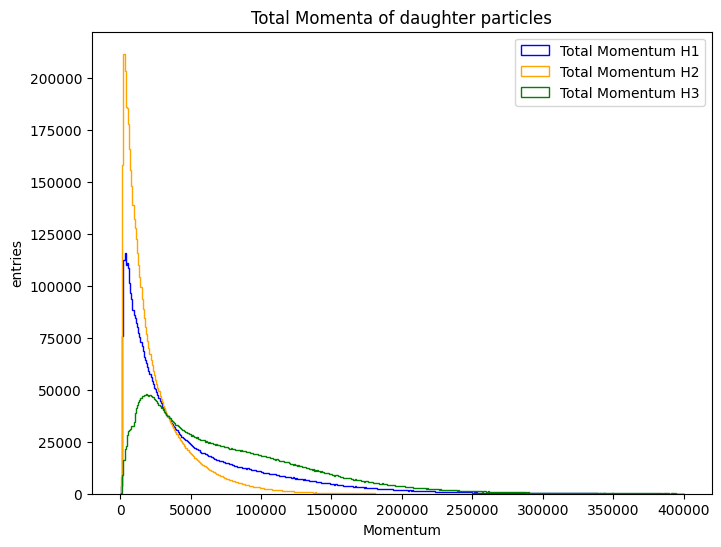

In [9]:
# histogram of total momentum of each of the three daughters
n_bins = 500
x_min, x_max =-10, 400000

fig, ax = plt.subplots(figsize=(8, 6))

counts, bin_edges, _ = ax.hist(
    H1_Ptot,
    bins=n_bins,
    range=(x_min, x_max),
    histtype="step",
    label="Total Momentum H1",
    color="blue"
)

counts, bin_edges, _ = ax.hist(
    H2_Ptot,
    bins=n_bins,
    range=(x_min, x_max),
    histtype="step",
    label="Total Momentum H2",
    color="orange"
)

counts, bin_edges, _ = ax.hist(
    H3_Ptot,
    bins=n_bins,
    range=(x_min, x_max),
    histtype="step",
    label="Total Momentum H3",
    color="green"
)

ax.set_xlabel("Momentum")
ax.set_ylabel("entries")
ax.set_title("Total Momenta of daughter particles")
ax.legend()


Now plot the total momentum for the mother (M_Ptot) this about how to calculate this from the information available

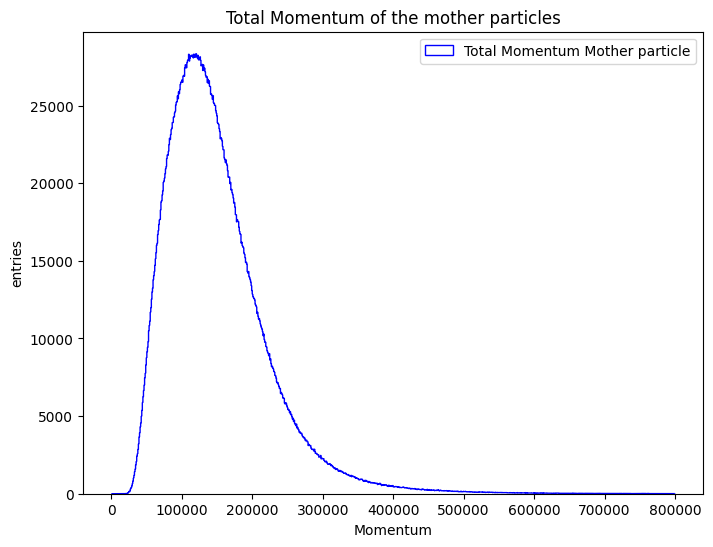

In [10]:
#use the histogram plotting tools, plot the momentum of the mother

# calculation of the momentum of the mother particle M_Ptot and add the results into an array
M_Ptot = []
for i in range(0, len(h1_px)):
  p_b = np.sqrt((h1_px[i] + h2_px[i] + h3_px[i])**2 + (h1_py[i] + h2_py[i] + h3_py[i])**2 + (h1_pz[i] + h2_pz[i] + h3_pz[i])**2)
  M_Ptot.append(p_b)


# histogram of the total momentum of the mother particle
n_bins = 1000
x_min, x_max =-10, 800000

fig, ax = plt.subplots(figsize=(8, 6))

counts, bin_edges, _ = ax.hist(
    M_Ptot,
    bins=n_bins,
    range=(x_min, x_max),
    histtype="step",
    label="Total Momentum Mother particle",
    color="blue"
)

ax.set_xlabel("Momentum")
ax.set_ylabel("entries")
ax.set_title("Total Momentum of the mother particles")
ax.legend()


In [11]:
# definition of a function to read branches of a tree as numpy arays (not absolutely necessary, but I thought it would make some things easier)
def get_arr(name_var):
  arr=tree[f"{name_var}"].array(library="np")
  return arr


Let's take a look at the whole data file that is available to us by looking at one specific entry - for example the number 45th entry in your array...

In [12]:
# print the 45th entry from your array(s) together with the variable name, maybe in a nice list or table.

# dictionary to make iterating through variables easier
data_dictionary = {0: "H1_PX",
                   1: "H1_PY",
                   2: "H1_PZ",
                   3: "H1_ProbK",
                   4: "H1_ProbPi",
                   5: "H1_Charge",
                   6: "H1_isMuon",
                   7: "H1_IPChi2",
                   8: "H2_PX",
                   9: "H2_PY",
                   10: "H2_PZ",
                   11: "H2_ProbK",
                   12: "H2_ProbPi",
                   13: "H2_Charge",
                   14: "H2_isMuon",
                   15: "H2_IPChi2",
                   16: "H3_PX",
                   17: "H3_PY",
                   18: "H3_PZ",
                   19: "H3_ProbK",
                   20: "H3_ProbPi",
                   21: "H3_Charge",
                   22: "H3_isMuon",
                   23: "H3_IPChi2",
                   24: "B_FlightDistance",
                   25: "B_VertexChi2"
                   }

# writing small arrays (containing the name and the 45th entry of every element of the data file) into an array of all the data from line 44
table_data = []
for i in range(0, len(data_dictionary)):
  arr = get_arr(data_dictionary[i])
  name = data_dictionary[i]
  line_45 = arr[44]
  arr_45 = [name, line_45]
  table_data.append(arr_45)

# Table
header = ["Name", "Value"]

from tabulate import tabulate       # useful to make a nice table, but there are other options as well

print(tabulate(table_data, header, tablefmt="grid"))    # printing the table with the 45th entry of each variable


+------------------+----------------+
| Name             |          Value |
+==================+================+
| H1_PX            | -1634.78       |
+------------------+----------------+
| H1_PY            |   838.663      |
+------------------+----------------+
| H1_PZ            | 15416.9        |
+------------------+----------------+
| H1_ProbK         |     0.00200036 |
+------------------+----------------+
| H1_ProbPi        |     0.949091   |
+------------------+----------------+
| H1_Charge        |     1          |
+------------------+----------------+
| H1_isMuon        |     0          |
+------------------+----------------+
| H1_IPChi2        |   312.785      |
+------------------+----------------+
| H2_PX            | -3456.16       |
+------------------+----------------+
| H2_PY            |  -328.793      |
+------------------+----------------+
| H2_PZ            | 21752.8        |
+------------------+----------------+
| H2_ProbK         |     0.00345078 |
+-----------

We have now completed the initial steps and begun to work through what we need to with the data. This is a perfect moment to take a coffee!

Having discovered all of the relevant information about our daughter particles, we need to combine the measurements about them into a single mother - which will be our B<sup>+</sup> or our B<sup>-</sup>

Having found our momentum and energy, we can use these quantities to find our experimental mass (not the theoretical mass as we have used for the reconstruction).

When we calculate this, we will get a distribution of masses. This is due to errors in the measurements made either by the detector, or in the experiment itself. We hope to have a reasonably narrow peak to work with, but, sometimes this is not possible.

Additionally there will be other particles in the detector - which means our daughters might have come from two or even three different processes. Events which don't come from the same process will give a higher or lower mass than we are looking for. This is typically called the *background* while events which come from our event of interest are called the *signal*

In [ ]:
#First find the energy (you might have to do some physics thinking here)

# The using the total momentum find the reconstructed mass of the B

# Now write your new variables to an array

#Now plot a histogram of the range of masses of the B meson.

#Does this match what we would expect from theory?

#What are the features of your plot that you see?

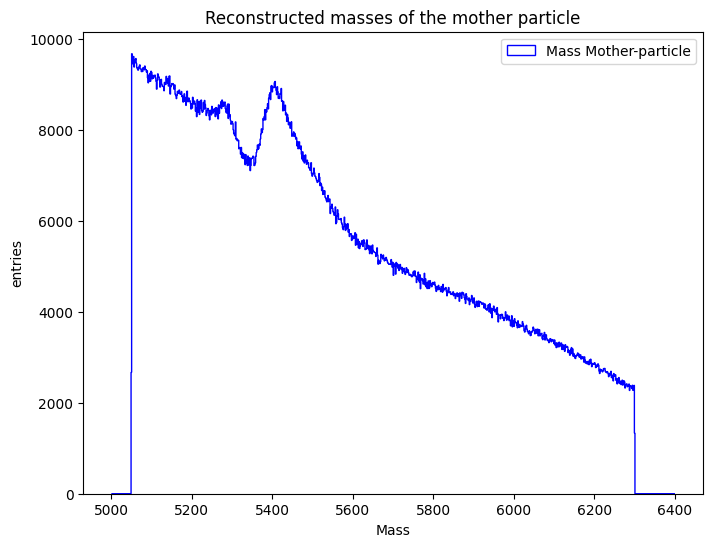

In [13]:

# mass K
m_k = 493.677 # MeV/c^2

# calculating the energies and writing them into arrays for each daughter particle
e1_arr = []
for i in range(0, len(H1_Ptot)):
  e = np.sqrt(H1_Ptot[i]**2 + m_k**2)
  e1_arr.append(e)

e2_arr = []
for i in range(0, len(H2_Ptot)):
  e = np.sqrt(H2_Ptot[i]**2 + m_k**2)
  e2_arr.append(e)

e3_arr = []
for i in range(0, len(H3_Ptot)):
  e = np.sqrt(H3_Ptot[i]**2 + m_k**2)
  e3_arr.append(e)

# calculating the total energy of the mother particle (B_Etot)
B_Etot = []
for i in range(0, len(e1_arr)):
  E = e1_arr[i] + e2_arr[i] + e3_arr[i]
  B_Etot.append(E)

# calculating the mass of the mother particle (B_Mtot)
B_Mtot = []
for i in range(0, len(M_Ptot)):
  m = np.sqrt(B_Etot[i]**2 - M_Ptot[i]**2)
  B_Mtot.append(m)



# histogram of masses of the mother particle
n_bins = 1000
x_min, x_max = 5000, 6400

fig, ax = plt.subplots(figsize=(8, 6))

counts, bin_edges, _ = ax.hist(
    B_Mtot,
    bins=n_bins,
    range=(x_min, x_max),
    histtype="step",
    label="Mass Mother-particle",
    color="blue"
)
ax.set_xlabel("Mass")
ax.set_ylabel("entries")
ax.set_title("Reconstructed masses of the mother particle")
ax.legend()


In [ ]:
#Does this match what we would expect from theory?
#   - According to the theory, the mass of a charged b-meson is about 5279MeV/c^2, which is about the first small peak in the diagram. Since
#     we for now only reconstructed masses without making sure the three daughter particles actually add up to a B+ or B- meson, this diagram
#     can very well include masses of other particles as well and not only B-mesons.
#

#What are the features of your plot that you see?
#   - there are no mother-particles with a mass lowerthan about 5050 or higher than 6300 units
#   - generally the number of particles with each mass is dropping linearly with local maxima around 5300 and 5450 units and a local minimum around 5375
#

We know that some of our particles are the B+ and some are the B- particle. There will also be some particles in our system that are not coming from a genuine B+/- or are a B+/- but are not constructed from Kaons.

We have some tools available to help:-

  *  During detection, software attributes the probability of a particle being a Kaon or a Pion (in the H1_ProbK or H1_ProbPi variable)
  * The detector also knows if the particle was a Muon - since it has detectors specifically for these. So it can attribute a 0 or a 1 to this probability
  * The reconstructed vertex has a some kind of quality associated with it (we call this the Vertex χ2 (this is the variable B_VertexChi2). This is the statistical measure that determines how well we found a single point to be the source of all three particles.



In order to get a better result, we should select our data to have the properties we desire and make some rules (often called a selection) to cut away data we don't want to include for various reasons. e.g. we know we don't have any muons in our decay - so any time H1/H2/H3 are a muon they should be excluded. The other variables are not so clear - so we can plot them to make a decision.

Text(0, 0.5, 'entries')

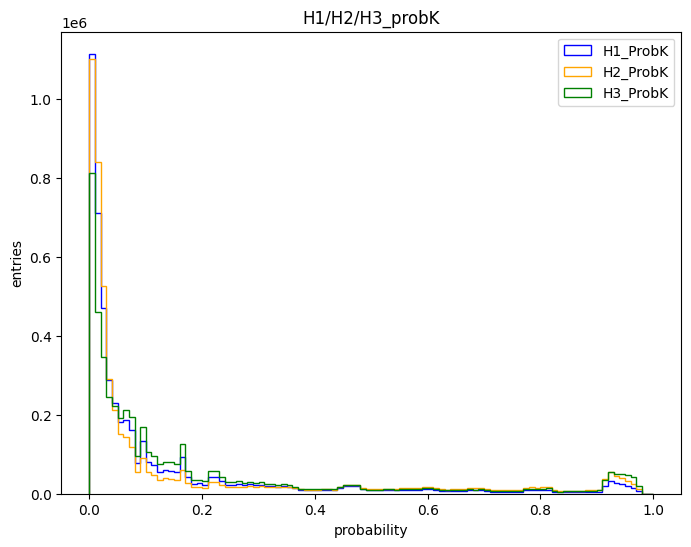

In [14]:
#Make plots of H1/H2/H3 _ProbK on one plot

H1_ProbK = get_arr("H1_ProbK")
H2_ProbK = get_arr("H2_ProbK")
H3_ProbK = get_arr("H3_ProbK")

# histogram
n_bins = 100
x_min, x_max = 0, 1

fig, ax = plt.subplots(figsize=(8, 6))

counts, bin_edges, _ = ax.hist(
    H1_ProbK,
    bins=n_bins,
    range=(x_min, x_max),
    histtype="step",
    label="H1_ProbK",
    color="blue"
)

counts, bin_edges, _ = ax.hist(
    H2_ProbK,
    bins=n_bins,
    range=(x_min, x_max),
    histtype="step",
    label="H2_ProbK",
    color="orange"
)

counts, bin_edges, _ = ax.hist(
    H3_ProbK,
    bins=n_bins,
    range=(x_min, x_max),
    histtype="step",
    label="H3_ProbK",
    color="green"
)

ax.legend()
ax.set_title("H1/H2/H3_probK")
ax.set_xlabel("probability")
ax.set_ylabel("entries")


Text(0, 0.5, 'entries')

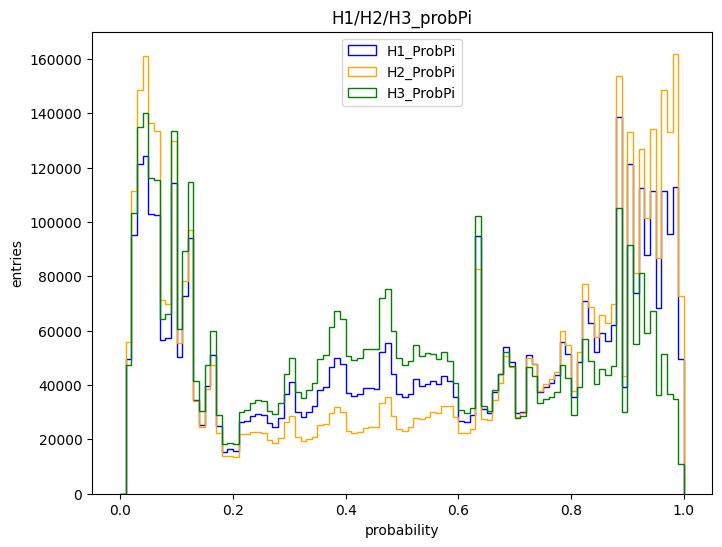

In [15]:
# Do the same for the Probability of being a Pion. Do these distributions match expectations?

H1_ProbPi = get_arr("H1_ProbPi")
H2_ProbPi = get_arr("H2_ProbPi")
H3_ProbPi = get_arr("H3_ProbPi")

# histogram
n_bins = 100
x_min, x_max = 0, 1

fig, ax = plt.subplots(figsize=(8, 6))

counts, bin_edges, _ = ax.hist(
    H1_ProbPi,
    bins=n_bins,
    range=(x_min, x_max),
    histtype="step",
    label="H1_ProbPi",
    color="blue"
)

counts, bin_edges, _ = ax.hist(
    H2_ProbPi,
    bins=n_bins,
    range=(x_min, x_max),
    histtype="step",
    label="H2_ProbPi",
    color="orange"
)

counts, bin_edges, _ = ax.hist(
    H3_ProbPi,
    bins=n_bins,
    range=(x_min, x_max),
    histtype="step",
    label="H3_ProbPi",
    color="green"
)

ax.legend()
ax.set_title("H1/H2/H3_probPi")
ax.set_xlabel("probability")
ax.set_ylabel("entries")


In [ ]:
# The first plot above shows the probability of a daughter particle being a Kaon. What we can see is, that there are a lot of particles
# with a low probability (<10%) of being a Kaon, and very little particles with a hight probability (>90%) of being a Kaon, however we can
# see a small peak in numbers between probabilities of 90% to 100%. Additionally, there are only rather a little number of particles
# with a probability of beint a Kaon anywhere between 20% and 90%.
# The second plot of probabilities of a particle being a Pion looks quite different: again, a lot of particles have a low probability (<20%)
# to be a pion, but also a lot of particles have a probability higher than 80%. In between 20 and 80%, the number of particles with these
# probabilities also does not die down, but stays relatively high everywhere in comparison to the numbers in both ends.
#
# Taken both graphs together, we can see that both probabilities do not necessarily add up to 100% for each particle (so if one particle has
# a probability of 40% to be a Kaon, it does not have to have a probability of 60% to be a Pion.
#
#

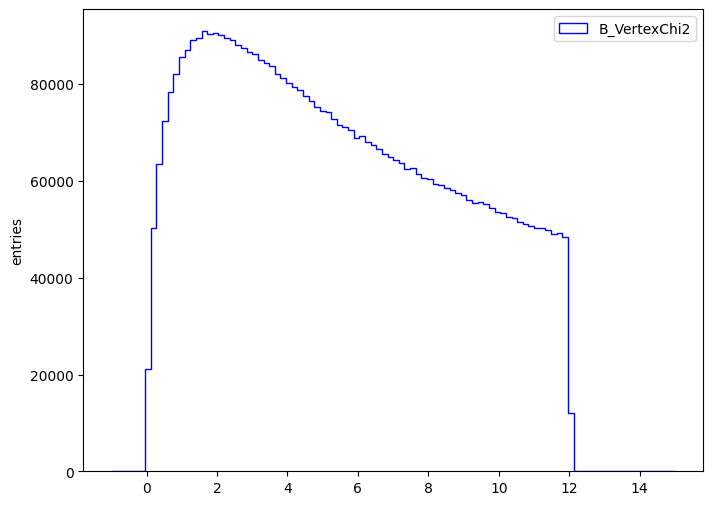

In [16]:
#For all our particles, make a plot of the B_VertexChi2

B_VertexChi2 = get_arr("B_VertexChi2")

# histogram
n_bins = 100
x_min, x_max = -1, 15

fig, ax = plt.subplots(figsize=(8, 6))

counts, bin_edges, _ = ax.hist(
    B_VertexChi2,
    bins=n_bins,
    range=(x_min, x_max),
    histtype="step",
    label="B_VertexChi2",
    color="blue"
)

ax.set_xlabel("")
ax.set_ylabel("entries")
ax.set_title("")
ax.legend()



#Feeling ambitious? Maybe make a 2d plot of Kaon and Pion Prob in a 2 dimensional analysis?


Using these plots, we can now make a preselection string. This is a text string that looks like

In [17]:
#This example is for each daughter particle to have a Probability of being a Pion being more than 90% and H1 to not be a muon
#This is not a good choice of selection - you should make your own :)
selection=("H1_ProbPi>0.9&H2_ProbPi>0.9&H3_ProbPi>0.9&!H1_isMuon&H2_isElectron&H3_isElephant")

In [18]:

# (I did not understand how exactly that selection string from above works, so I used a slightly different method)
import pandas as pd

# the full data from which some is selected
df = tree.arrays(library="pd")

# what is supposed to be selected under which conditions (a lot of data is icluded here to make the fitting of curves easier later)
selection3 = (
    (df["H1_ProbK"] > 0.1) &
    (df["H2_ProbK"] > 0.1) &
    (df["H3_ProbK"] > 0.1) &
    (df["H1_ProbPi"] < 0.9) &
    (df["H2_ProbPi"] < 0.9) &
    (df["H3_ProbPi"] < 0.9) &
    (df["H1_isMuon"] == 0) &
    (df["H2_isMuon"] == 0) &
    (df["H3_isMuon"] == 0) &
    (df["B_VertexChi2"] < 6)
)

# the new data (only the data from the old data is kept that fulfills the selection criteria)
df_selected3 = df[selection3]

# printing the lengths of the data just to check how much is in the selection in comparison to before
print(len(df))
print(len(df_selected3))


5135823
91962


In [19]:
#Now as a good check, we should see the effect of applying our cuts.
#On one histogram, plot the B meson mass, from both the tree (pre-cuts) and the CutTree (post-cuts)
#What do you notice about your histogram now?


# calculate the mass again for the particles in the selection:
# (Instead of doing the calculations again, this can probably be done by just selecting the already calculated masses from the
# original data that are also in this selection, but I did not find out how to do that in time.)

# read the correct branches as numpy arrays
h1_px_c = np.array(df_selected3["H1_PX"])
h1_py_c = np.array(df_selected3["H1_PY"])
h1_pz_c = np.array(df_selected3["H1_PZ"])
h2_px_c = np.array(df_selected3["H2_PX"])
h2_py_c = np.array(df_selected3["H2_PY"])
h2_pz_c = np.array(df_selected3["H2_PZ"])
h3_px_c = np.array(df_selected3["H3_PX"])
h3_py_c = np.array(df_selected3["H3_PY"])
h3_pz_c = np.array(df_selected3["H3_PZ"])


# calculate the total momenta
H1_Ptot_c = []
for i in range(0, len(h1_px_c)):
  p = np.sqrt(h1_px_c[i]**2 + h1_py_c[i]**2 + h1_pz_c[i]**2)
  H1_Ptot_c.append(p)

H2_Ptot_c = []
for i in range(0, len(h2_px_c)):
  p = np.sqrt(h2_px_c[i]**2 + h2_py_c[i]**2 + h2_pz_c[i]**2)
  H2_Ptot_c.append(p)

H3_Ptot_c = []
for i in range(0, len(h1_px_c)):
  p = np.sqrt(h3_px_c[i]**2 + h3_py_c[i]**2 + h3_pz_c[i]**2)
  H3_Ptot_c.append(p)


# calculate the momenta of B-Meson
M_Ptot_c = []
for i in range(0, len(h1_px_c)):
  p_b = np.sqrt((h1_px_c[i] + h2_px_c[i] + h3_px_c[i])**2 + (h1_py_c[i] + h2_py_c[i] + h3_py_c[i])**2 + (h1_pz_c[i] + h2_pz_c[i] + h3_pz_c[i])**2)
  M_Ptot_c.append(p_b)

# calculate the energies of the daughter particles
e1_arr_c = []
for i in range(0, len(H1_Ptot_c)):
  e = np.sqrt(H1_Ptot_c[i]**2 + m_k**2)
  e1_arr_c.append(e)

e2_arr_c = []
for i in range(0, len(H2_Ptot_c)):
  e = np.sqrt(H2_Ptot_c[i]**2 + m_k**2)
  e2_arr_c.append(e)

e3_arr_c = []
for i in range(0, len(H3_Ptot_c)):
  e = np.sqrt(H3_Ptot_c[i]**2 + m_k**2)
  e3_arr_c.append(e)

# calculate the total energy of B-meson
B_Etot_c = []
for i in range(0, len(e1_arr_c)):
  E = e1_arr_c[i] + e2_arr_c[i] + e3_arr_c[i]
  B_Etot_c.append(E)

# calculate the mass of the b-meson
B_Mtot_c = []
for i in range(0, len(M_Ptot_c)):
  m = np.sqrt(B_Etot_c[i]**2 - M_Ptot_c[i]**2)
  B_Mtot_c.append(m)



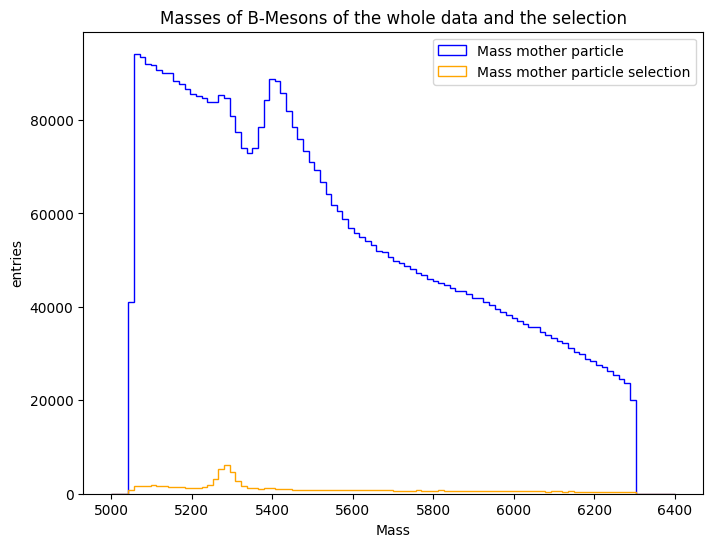

In [20]:
# histogram of masses of the mother particle of the whole data and the selection
n_bins = 100
x_min, x_max = 5000, 6400

fig, ax = plt.subplots(figsize=(8, 6))

counts, bin_edges, _ = ax.hist(
    B_Mtot,
    bins=n_bins,
    range=(x_min, x_max),
    histtype="step",
    label="Mass mother particle",
    color="blue"
)

counts, bin_edges, _ = ax.hist(
    B_Mtot_c,
    bins=n_bins,
    range=(x_min, x_max),
    histtype="step",
    label="Mass mother particle selection",
    color="orange"
)
ax.set_xlabel("Mass")
ax.set_ylabel("entries")
ax.set_title("Masses of B-Mesons of the whole data and the selection")
ax.legend()

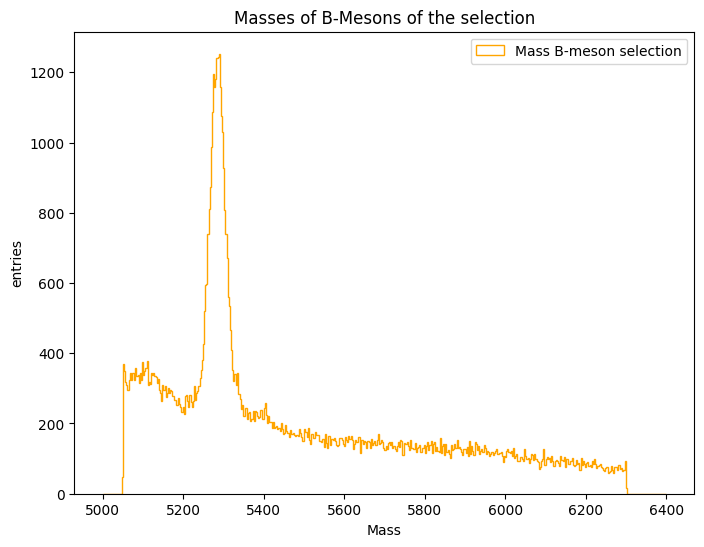

In [21]:
#You can also plot your selected data alone - this shape probably looks quite alot different to your first distribution!

# histogram only selected data
n_bins = 500
x_min, x_max = 5000, 6400

fig, ax = plt.subplots(figsize=(8, 6))

counts_s, bin_edges_s, _ = ax.hist(
    B_Mtot_c,
    bins=n_bins,
    range=(x_min, x_max),
    histtype="step",
    label="Mass B-meson selection",
    color="orange"
)

ax.set_xlabel("Mass")
ax.set_ylabel("entries")
ax.set_title("Masses of B-Mesons of the selection")
ax.legend()

#How do we count the number of events?

We now have a histogram of events that we have reconstructed as a B meson. But some of these events are caused by a co-incidence of events which would still occur if there were no B mesons actually produced. We call this the background. Background and signal are indistinguishable now as the detector cannot tell the difference and our cuts were unable to remove the events for physics reasons. We can do some statistical analysis, if we know the approximate shapes of our signal and our background. Just like a least-squares fitting we can run a fit routine to minimise the error between the fitted curve and our data. As an example, if we know our data has an exponential background and a gaussian signal:

![Gaussian+Exp Background](https://twiki.cern.ch/twiki/pub/RooStats/RooStatsTutorialsJune2013/GausExpModelFit.png)

Here the red line represents our signal, the blue dotted line is our background and the solid blue line is our combined curve. The graph also shows the number of signal events and the number of background events. The signal now is a tiny fraction of the total data shown in the plot.

In order to do this, we need to build a fit model, around which the software can try to fit our data.

We use RooFit for this, which includes:
* Gaussian
* Exponential
* Chebychev
* Crystal Ball
* Breit-Wigner

As well as several other choices.

Typically exponential and Chebychev functions are used for background and Gaussian, Crystal Ball and Breit-Wigner are used for signal. We can also combine them (e.g. 1 crystal ball, 1 gaussian, 1 exponential) in various ways.

In [22]:
# Probably handy to use a package like lmfit to help us with the models we might want to use, then use scipy to fit

!pip install lmfit

# check out its documentation for what shapes it can handle for you! https://pypi.org/project/lmfit/

# it can do the whole fitting story and output results too :)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.7/97.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 5.3 MB/s eta 0:00:00


In [ ]:
#use my example of creating a PDF (far far) above to do a fit to your data. Start with one component, think about making a number 2 component plot - so we have a part for the background and a part for the signal.

# if your cut is very strict above, you may actually get better results by being less strict, give yourself more data and more events to run through the fitting procedure.

<>:62: SyntaxWarning: invalid escape sequence '\m'
<>:62: SyntaxWarning: invalid escape sequence '\s'
<>:62: SyntaxWarning: invalid escape sequence '\m'
<>:62: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-2737190493.py:62: SyntaxWarning: invalid escape sequence '\m'
  label=f"Gaussian fit for peak data\n$\mu={fit_mu:.3f}$, $\sigma={fit_sigma:.3f}$",
/tmp/ipython-input-2737190493.py:62: SyntaxWarning: invalid escape sequence '\s'
  label=f"Gaussian fit for peak data\n$\mu={fit_mu:.3f}$, $\sigma={fit_sigma:.3f}$",


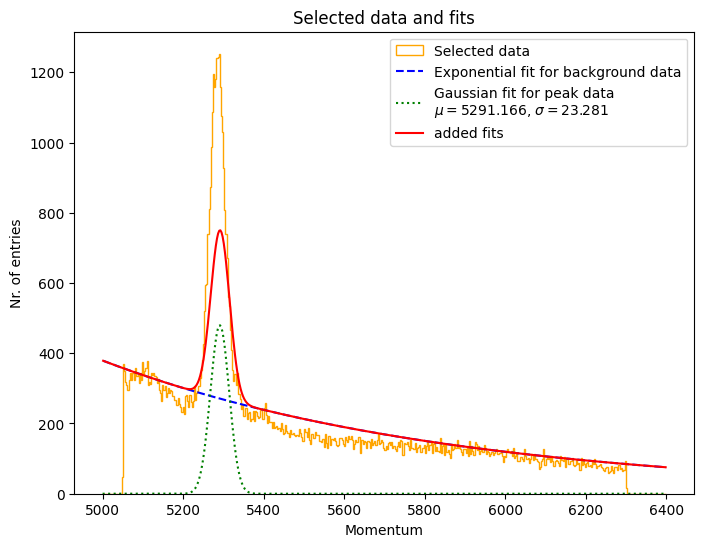

In [23]:

import lmfit
from lmfit.models import ExponentialModel
from lmfit.models import GaussianModel

bin_centers_s = 0.5 * (bin_edges_s[1:] + bin_edges_s[:-1])

n_bins = 500
x_min, x_max = 5000, 6400


# Exponential Fit for the background data
model = ExponentialModel()
params = model.guess(counts_s, bin_centers_s)

result = model.fit(counts_s, params, x=bin_centers_s)


# Gaussian Fit for the peak

# make a new array of data to make the fit only for the peak
new_B_Mtot_c = []
for i in range(0, len(B_Mtot_c)):
  if 5250 <= B_Mtot_c[i] <= 5350:
    new_B_Mtot_c.append(float(B_Mtot_c[i]))

fit_mu, fit_sigma = norm.fit(new_B_Mtot_c)
x = np.linspace(x_min, x_max, 500)
pdf = norm.pdf(x, fit_mu, fit_sigma)
bin_width = (x_max - x_min) / n_bins
fit_y = pdf * n_entries * bin_width


# adding both fits to get an overall fit
full_result = np.add(result.best_fit, fit_y)


# histogram

fig, ax = plt.subplots(figsize=(8, 6))

counts, bin_edges, _ = ax.hist(
    B_Mtot_c,
    bins=n_bins,
    range=(x_min, x_max),
    histtype="step",
    color="orange",
    label="Selected data"
)

ax.plot(
    bin_centers_s,
    result.best_fit,
    color="blue",
    label="Exponential fit for background data",
    linestyle="--"
)

ax.plot(
    x,
    fit_y,
    color="green",
    label=f"Gaussian fit for peak data\n$\mu={fit_mu:.3f}$, $\sigma={fit_sigma:.3f}$",
    linestyle=":"
)

ax.plot(
    bin_centers_s,
    full_result,
    color="red",
    label="added fits"
)

ax.set_title("Selected data and fits")
ax.set_xlabel("Momentum")
ax.set_ylabel("Nr. of entries")
ax.legend()

In [ ]:
#use my example of creating a PDF (far far) above to do a fit to your data. Start with one component, think about making a number 2 component plot - so we have a part for the background and a part for the signal.

# if your cut is very strict above, you may actually get better results by being less strict, give yourself more data and more events to run through the fitting procedure.

Using this structure, you can in theory build whatever models you like!

Some recommendations (but not necessary to do all):-



*   Gauss+Exponential (as above)
*   Crystal Ball + Exponential
*   Gauss+Crystal Ball+Exponential (now you need to weigh the two signal peaks and then the total signal against total background)
*   Gauss+Chebychev
*   Two Crystal Balls + Exponential

So how good was the fit, and how many events do you have?

You can use the signal shape, the bin widths and the quad from scipy.integrate function to "count" how many events lie under your signal peak,  not including the background events - this is what we actually want.

It will also return to you an error - check in the scipy documentation about what that actually means....

In [ ]:
#find the area under your curve(s)! maybe make a pretty little table...

In [25]:
import scipy.integrate as integrate

area_exp = integrate.simpson(result.best_fit, bin_centers_s)
print("area_exp=", area_exp)

area_gauss = integrate.simpson(fit_y, x)
print("area_gauss=", area_gauss)

area_exp= 262534.09058568714
area_gauss= 28000.0


Source of the code for the integration: https://docs.scipy.org/doc/scipy/tutorial/integrate.html

#Counting

So we have now loaded our data; we have reconstructed information about the mother B meson and we have cut away any data which looks like it might not be what we are looking for. We have then plotted histograms of the mass of the B meson and used this to fit a model, a function to describe the events there. We now have to identify which of our events belong to the B<sup>+</sup> and how many of them belong to B<sup>-</sup>.

To do this, should split out data into two groups (and throw away data which doesn't comply with either decay)

We will be looking for the events which are


B<sup>+</sup>->K<sup>+</sup> + K<sup>+</sup>  + K<sup>-</sup>

or

B<sup>-</sup>->K<sup>-</sup> + K<sup>-</sup>  + K<sup>+</sup>

We can look for the number of positive and negative charges in H1, H2 and H3 (using the variable ```H1_Charge``` etc.). If we have 0 or 3 positive charges, we should throw the event away and if we have 1 it should be assigned be a B<sup>-</sup>, with 2 it should be a B<sup>+</sup>

In [26]:
# sort into no-B-Meson, Bplus and Bminus

h1_charge = np.array(df_selected3["H1_Charge"])
h2_charge = np.array(df_selected3["H2_Charge"])
h3_charge = np.array(df_selected3["H3_Charge"])

# make an array that only contains information on if something is Bminus (-1), Bplus(+1), or nothing of both (0)
B_type_arr = []
for i in range (0, len(df_selected3)):
  h1_c = h1_charge[i]
  h2_c = h2_charge[i]
  h3_c = h3_charge[i]
  add_c = h1_c + h2_c + h3_c
  if add_c==-3 or add_c==3:
    B_type_arr.append(0)
  elif add_c==-1:
    B_type_arr.append(-1)
  elif add_c==1:
    B_type_arr.append(1)


# count the number of Bplus, Bminus and others
Bplus = 0
Bminus = 0
other = 0
for i in range(0, len(B_type_arr)):
  if B_type_arr[i]==-1:
    Bminus+=1
  elif B_type_arr[i]==0:
    other+=1
  elif B_type_arr[i]==1:
    Bplus+=1


# print the numbers for comparison
print("number B+=", Bplus)
print("number B-=", Bminus)
print("number other=", other)
print("total number of particles=", Bplus+Bminus+other)


number B+= 47329
number B-= 44633
number other= 0
total number of particles= 91962


Once we have defined if it's a B<sup>+</sup> or a B <sup>-</sup>, we should go ahead and ensure the pre-selection is applied and then plot our B mass, and fit the model to find the yield.

We can then calculate the assymetry from this equation:

$A=\frac{(N^{B-}-N^{B+})}{(N^{B-}+N^{B+})}$

Where N<sup>B+/- </sup> is the number of events found from the fitted yield of the signal from each data set.

The uncertainty on this result is given by:

$\sigma_A=\sqrt\frac{1-A^2}{N^{B-}+N^{B+}}$

Calculate these two values for your data and print them below:

In [ ]:
#Here do your calculation of the final result

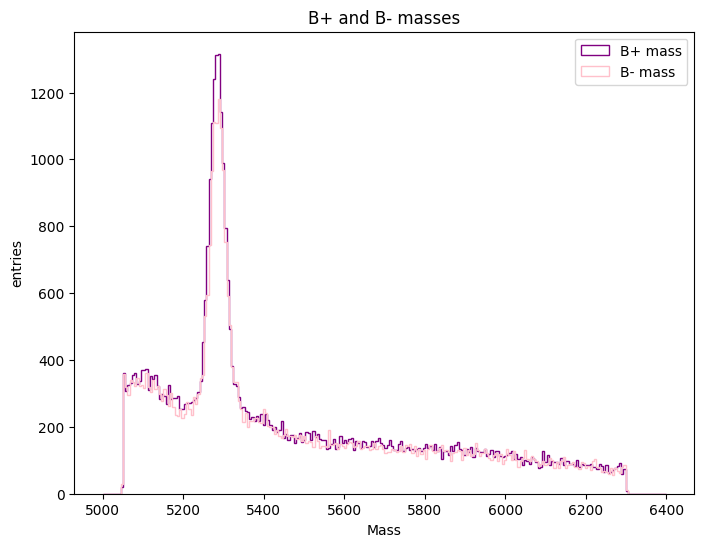

In [27]:
# plot b mass for both bplus and bminus

Bplus_Mtot = []
Bminus_Mtot = []
for i in range(0, len(B_type_arr)):
  if B_type_arr[i]==-1:
    Bminus_Mtot.append(B_Mtot_c[i])
  elif B_type_arr[i]==+1:
    Bplus_Mtot.append(B_Mtot_c[i])



# histogram of Bplus- and Bminus-Masses
n_bins = 250
x_min, x_max = 5000, 6400

ig, ax = plt.subplots(figsize=(8, 6))

counts_Bp, bin_edges_Bp, _ = ax.hist(
    Bplus_Mtot,
    bins=n_bins,
    range=(x_min, x_max),
    histtype="step",
    color="purple",
    label="B+ mass"
)

counts_Bm, bin_edges_Bm, _ = ax.hist(
    Bminus_Mtot,
    bins=n_bins,
    range=(x_min, x_max),
    histtype="step",
    color="pink",
    label="B- mass"
)

ax.set_xlabel("Mass")
ax.set_ylabel("entries")
ax.set_title("B+ and B- masses")
ax.legend()


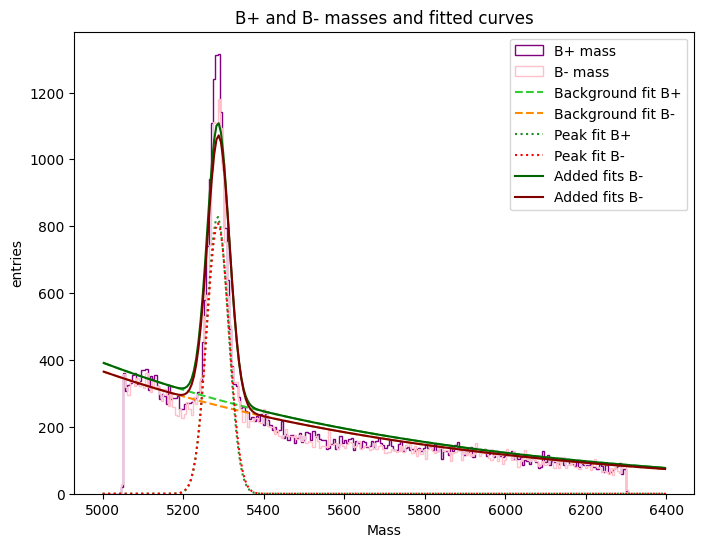

In [28]:

# fitting models to B+

# background fit

bin_centers_Bp = 0.5 * (bin_edges_Bp[1:] + bin_edges_Bp[:-1])

model_Bp = ExponentialModel()
params_Bp = model_Bp.guess(counts_Bp, bin_centers_Bp)

result_Bp = model_Bp.fit(counts_Bp, params_Bp, x=bin_centers_Bp)


# fit for peak

new_Bplus_Mtot = []
for i in range(0, len(Bplus_Mtot)):
  if 5225 <= Bplus_Mtot[i] <= 5350:
    new_Bplus_Mtot.append(float(Bplus_Mtot[i]))


# Fit a normal distribution to the data
# norm.fit returns the fitted mean and standard deviation
fit_mu_Bp, fit_sigma_Bp = norm.fit(new_Bplus_Mtot)

# Create x values for drawing the fitted function
x_Bp = np.linspace(x_min, x_max, 250)

# Evaluate the fitted Gaussian probability density function
pdf_Bp = norm.pdf(x_Bp, fit_mu_Bp, fit_sigma_Bp)

# Convert PDF to expected histogram counts
# (ROOT does this internally; here we scale manually)
bin_width_Bp = (x_max - x_min) / n_bins
fit_y_Bp = pdf_Bp * n_entries * bin_width_Bp

# full result
full_result_Bp = np.add(result_Bp.best_fit, fit_y_Bp)


# fitting models to B-

# background fit

bin_centers_Bm = 0.5 * (bin_edges_Bm[1:] + bin_edges_Bm[:-1])

model_Bm = ExponentialModel()
params_Bm = model_Bm.guess(counts_Bm, bin_centers_Bm)

result_Bm = model_Bm.fit(counts_Bm, params_Bm, x=bin_centers_Bm)


# fit for peak

new_Bminus_Mtot = []
for i in range(0, len(Bminus_Mtot)):
  if 5225 <= Bminus_Mtot[i] <= 5350:
    new_Bminus_Mtot.append(float(Bminus_Mtot[i]))

# Fit a normal distribution to the data
# norm.fit returns the fitted mean and standard deviation
fit_mu_Bm, fit_sigma_Bm = norm.fit(new_Bminus_Mtot)

# Create x values for drawing the fitted function
x_Bm = np.linspace(x_min, x_max, 250)

# Evaluate the fitted Gaussian probability density function
pdf_Bm = norm.pdf(x_Bm, fit_mu_Bm, fit_sigma_Bm)

# Convert PDF to expected histogram counts
# (ROOT does this internally; here we scale manually)
bin_width_Bm = (x_max - x_min) / n_bins
fit_y_Bm = pdf_Bm * n_entries * bin_width_Bm

# full result
full_result_Bm = np.add(result_Bm.best_fit, fit_y_Bm)




# histogram

n_bins = 250
x_min, x_max = 5000, 6400

ig, ax = plt.subplots(figsize=(8, 6))

counts_Bp, bin_edges_Bp, _ = ax.hist(
    Bplus_Mtot,
    bins=n_bins,
    range=(x_min, x_max),
    histtype="step",
    color="purple",
    label="B+ mass"
)

counts_Bm, bin_edges_Bm, _ = ax.hist(
    Bminus_Mtot,
    bins=n_bins,
    range=(x_min, x_max),
    histtype="step",
    color="pink",
    label="B- mass"
)
ax.plot(
    bin_centers_Bp,
    result_Bp.best_fit,
    color="limegreen",
    label="Background fit B+",
    linestyle="--"
)
ax.plot(
    bin_centers_Bm,
    result_Bm.best_fit,
    color="darkorange",
    label="Background fit B-",
    linestyle="--"
)
ax.plot(
    x_Bp,
    fit_y_Bp,
    color="forestgreen",
    label="Peak fit B+",
    linestyle=":"
)
ax.plot(
    x_Bm,
    fit_y_Bm,
    color="red",
    label="Peak fit B-",
    linestyle=":"
)
ax.plot(
    bin_centers_Bp,
    full_result_Bp,
    color="darkgreen",
    label="Added fits B-"
)
ax.plot(
    bin_centers_Bm,
    full_result_Bm,
    color="maroon",
    label="Added fits B-"
)


ax.set_xlabel("Mass")
ax.set_ylabel("entries")
ax.set_title("B+ and B- masses and fitted curves")
ax.legend()



In [29]:
# area under peak fit

area_peak_Bp = integrate.simpson(fit_y_Bp, bin_centers_Bp)
print("area peak B+ =", area_peak_Bp)

area_peak_Bm = integrate.simpson(fit_y_Bm, bin_centers_Bm)
print("area peak B- =", area_peak_Bm)

area peak B+ = 55775.99999999998
area peak B- = 55775.99999999997


In [30]:
# Calculation of assymetry

A = (area_peak_Bm - area_peak_Bp)/(area_peak_Bm + area_peak_Bp)

print("Asymmetry=", A)

uncA = np.sqrt((1-A**2)/(area_peak_Bm + area_peak_Bp))

print("Uncertainty of A =", uncA)

Asymmetry= -6.522480649547681e-17
Uncertainty of A = 0.002994065654783148


In [ ]:
# Thoughts about the last parts of the analysis:
#
# In the purple and pink histogram ("B+ and B- mass"), we can see that the histograms look very similar with almost the same shape of the data
# and the peak of B+ (in purple) being only slightly higher than the one of B- (in pink). We can see the same for the fitted curves. This
# difference being only very small then leads to them having almost the same yields, and that in turn to a very small asymmetry. In fact, the
# asymmetry is about 15 orders of magnitude smaller than the uncertainty, which means that the result (the asymmetry) is not statistically
# significant and the yields of B+ and B- are basically the same.
# My gaussian fits to the peaks are not perfect, if they were better, the asymmetry were maybe a little larger, but since the difference is
# also very small in the histograms, I assume that even with a better fit the asymmetry would not be statistically significant.
# I therefore conclude that this LHCb-experiment produced similar numbers of B+ and B- mesons.

#Congratulations!

You just made your first LHCb physics analysis. Does this seem like a reasonable result? Did we explain why we have an excess of mass in the Universe?

In [ ]:
# Since as described before in this analysis the asymmetry between B+ and B- mesons is not statistically significant, this does not explain
# why we have an exess of mass in the universe. Disregarding the fact that we do have that exess of mass and that there need to be processes
# that produce more matter than antimatter, this result here rather supports the models that say that there should be the same amounts of
# matter and antimatter created. However since we did not take all of the possible processes into account that the mother particle can decay
# into, there might be some explanation in those processes as well.
# But once again, since my fits are not perfect, and not as good as I would like to have them, more skilled data-analysts might come to a
# different result, that the might explain the excess of mass in the Universe.

## **Bonus content only below here:**

To make a further anaysis, we can look into the intermediate processes.

We have so far considered only that the B meson ultimately decays into three kaons. It may be that on the way, the B meson first decays into a Kaon and another particle, and then from that particle to two Kaons.

We would expect this to be one of three possible modes (for B<sup>+</sup>):

$R^{++} \rightarrow K_1^+ +K_2^+$

(we don't expect this to happen because of the like charges in the Kaons)

$R^0 \rightarrow K_1^+ +K_3^-$

$R^0 \rightarrow K_2^+ +K_3^-$

(Expect symmetric arrangements for B<sup>-</sup>)

To analyse the intermediate states we can measure the invarient masses of the intermediate states and then plot them on what is called a Dalitz plot (this is a 2D plot with two different two body decays (from the three body decay) on each axis)

![Dalitz Plot](https://slideplayer.com/slide/15960097/88/images/15/Dalitz+plot%3A+%CE%9B+c+%2B+%E2%86%92%F0%9D%91%9D+%F0%9D%90%BE+%E2%88%92+%F0%9D%9C%8B+%2B.jpg)


In [ ]:
#Define a function to find the invarient mass of two given Kaons

In [ ]:
#Then, ensuring you're still taking the data after the selection, make a Dalitz plot. This is a 2-D scatter plot (use e.g. TH2F to make the plot where we used TH1F before)
#Choose an appropriate binning in your scatter

We can further improve our plot, since two sets of particles on each axis are exactly the same (one positive Kaon, one negative Kaon). So we can plot the maximum of the two values on one axis and the minimum on the other. We can use a quick numpy check and then plot those values.

In [ ]:
#Make the revised Dalitz plot here for B+ mesons

In [ ]:
#Make the revised Dalitz plot here for B- mesons

In [ ]:
#Where we have a higher density of points (or a bigger value in the bin) this is indication of an intermediate resonance
#Check out the possible resonances you have found in the PDG (http://pdg.lbl.gov/2020/tables/contents_tables.html)